<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print('All required libraries installed and imported')

All required libraries installed and imported


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [3]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

#Display the top 10 records
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


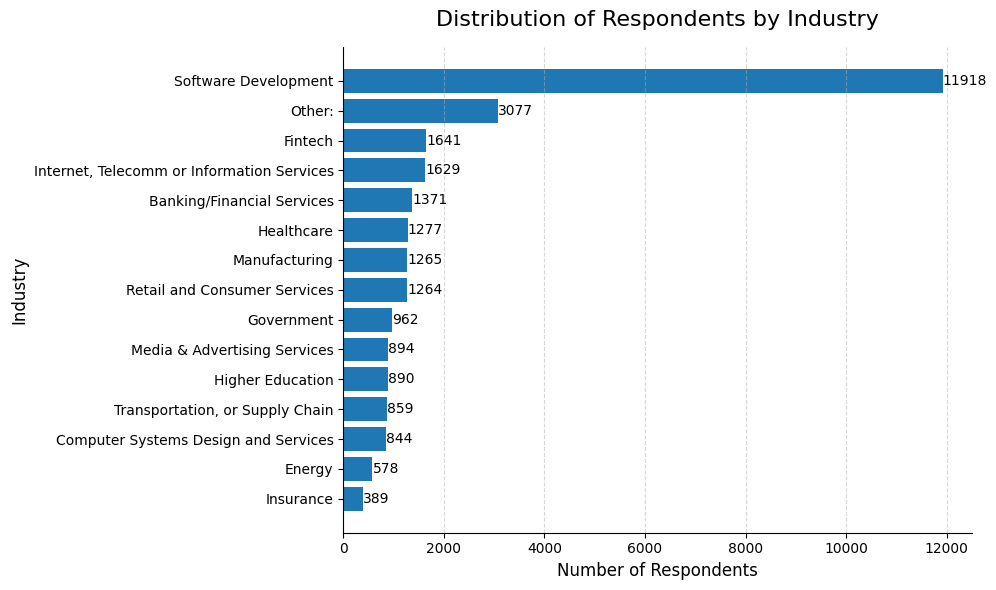

In [25]:
# Counting respondents by industry
industry_counts = df['Industry'].value_counts()
industry_counts = industry_counts.sort_values()

# Figure
plt.figure(figsize=(10, 6))

# Plot
bars = plt.barh(industry_counts.index, industry_counts.values)

# Titles and labels
plt.title('Distribution of Respondents by Industry', fontsize=16, pad=15)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Industry', fontsize=12)

# Removing top/right spines for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adding value labels
for i, v in enumerate(industry_counts.values):
    plt.text(v + 1, i, str(v), va='center')

# Adding subtle grid
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Tight layout
plt.tight_layout()

plt.show()

In [26]:
# From the horizontal bar plot we can see that most respondents tend to come from tech-related roles.
# There is a long tail distribution which means that there are many industries with small counts rather than a few evenly distributed ones.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [28]:
# Dropping missing values
comp = df['ConvertedCompYearly'].dropna()

# Basic statistics
mean_val = comp.mean()
median_val = comp.median()
std_val = comp.std()

print('Mean:', mean_val)
print('Median:', median_val)
print('Standard Deviation:', std_val)

threshold = mean_val + 3 * std_val

# Filtering outliers
high_outliers = comp[comp > threshold]

print('Threshold (Mean + 3*Std):', threshold)
print('Number of high outliers:', len(high_outliers))

# Viewing top outliers
print(high_outliers.sort_values(ascending=False).head())

Mean: 86155.28726264134
Median: 65000.0
Standard Deviation: 186756.97308629754
Threshold (Mean + 3*Std): 646426.206521534
Number of high outliers: 89
15837    16256603.0
12723    13818022.0
28379     9000000.0
17593     6340564.0
17672     4936778.0
Name: ConvertedCompYearly, dtype: float64


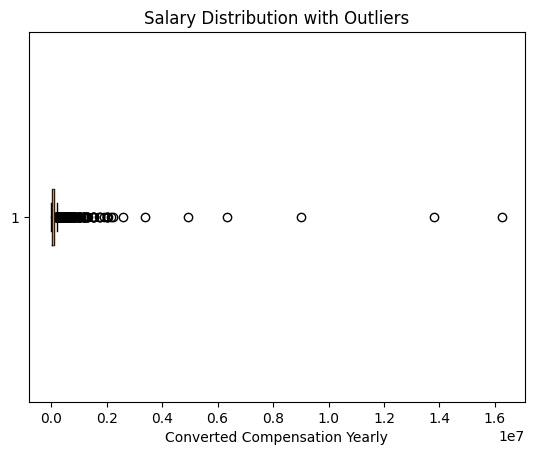

In [30]:
# We can also see some of the top outliers by creating a box plot
plt.figure()
plt.boxplot(comp, vert=False)
plt.title('Salary Distribution with Outliers')
plt.xlabel('Converted Compensation Yearly')
plt.show()

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [32]:
# Cleaning data
comp = df['ConvertedCompYearly'].dropna()

## IQR = Q3 - Q1
# Quartiles
Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)

# IQR
IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5


In [33]:
# Defining bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: -80177.25
Upper Bound: 220860.75


In [37]:
# We see that the lower bound has a negative value. This mathematically can happen, but in this case since we are examining salaries this are not realistic.
# The negative lower bound exists, because the distribution is right-skewed and there is a big IQR. This inflates the 1.5 × IQR term, causing a negative result.
# So we will set a lower bound limit of 0.

In [34]:
lower_bound = max(0, Q1 - 1.5 * IQR)

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: 0
Upper Bound: 220860.75


In [38]:
# Filtering outliers
outliers = comp[(comp < lower_bound) | (comp > upper_bound)]

print('Number of outliers:', len(outliers))

View extreme values
print(outliers.sort_values().head())      # lowest
print(outliers.sort_values(ascending=False).head())  # highest

Number of outliers: 978
38188    221000.0
8418     221713.0
39168    221746.0
39997    222000.0
36158    222000.0
Name: ConvertedCompYearly, dtype: float64
15837    16256603.0
12723    13818022.0
28379     9000000.0
17593     6340564.0
17672     4936778.0
Name: ConvertedCompYearly, dtype: float64


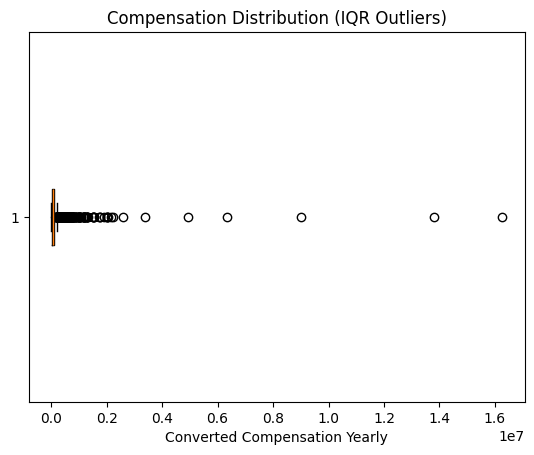

In [39]:
plt.figure()
plt.boxplot(comp, vert=False)

plt.title('Compensation Distribution (IQR Outliers)')
plt.xlabel('Converted Compensation Yearly')

plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [41]:
# New clean dataframe with values bigger that lower bound and smaller than upper bound

df_clean = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

In [43]:
# Dataframe size validation

print('Original dataset size:', df.shape)
print('Cleaned dataset size:', df_clean.shape)

# Number of rows removed
removed = df.shape[0] - df_clean.shape[0]
print('Rows removed (outliers):', removed)

Original dataset size: (65437, 114)
Cleaned dataset size: (22457, 114)
Rows removed (outliers): 42980


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
